# Cross-Dataset Comparison
**Project:** Evaluating the Reliability of Selected RAG Evaluation Metrics for Finance-Related QA
**Student:** Ayusha Shrestha

This notebook brings together the finalized results from all three datasets:
- `ragbench_finqa_ragas_results.csv` (finqa, n=15)
- `multihop_rag_final_results.csv` (MultiHop-RAG, n=15)
- `financebench_final_results.csv` (FinanceBench, n=16)

**Before running:** upload these three CSV files (already produced by the earlier
notebooks) to this Colab session's file area.

Produces: one combined long-format CSV for reference, and two summary charts for the
Evaluation and Discussion chapter.


## 1. Install/import libraries
Only `pandas` and `matplotlib` are needed for this step.

In [ ]:
!pip install -q pandas matplotlib
print("Libraries ready.")


Libraries ready.


## 2. Load the three result files

In [ ]:
import pandas as pd

finqa = pd.read_csv("ragbench_finqa_final_results.csv")
multihop = pd.read_csv("multihop_rag_final_results.csv")
financebench = pd.read_csv("financebench_final_results.csv")

print("finqa:", finqa.shape)
print("multihop:", multihop.shape)
print("financebench:", financebench.shape)


finqa: (15, 9)
multihop: (15, 7)
financebench: (16, 10)


## 3. Standardize columns and combine into one long-format table

In [ ]:
finqa_out = finqa[["id", "question", "question_type",
                    "faithfulness", "answer_relevancy",
                    "llm_context_precision_without_reference"]].copy()
finqa_out.columns = ["item_id", "question", "category",
                      "faithfulness", "answer_relevancy", "context_precision"]
finqa_out["dataset"] = "finqa"

multihop_out = multihop[["query", "question_type",
                          "faithfulness", "answer_relevancy", "context_precision"]].copy()
multihop_out.columns = ["question", "category",
                         "faithfulness", "answer_relevancy", "context_precision"]
multihop_out["item_id"] = ["multihop_" + str(i) for i in range(len(multihop_out))]
multihop_out["dataset"] = "MultiHop-RAG"

fb_out = financebench[["financebench_id", "question", "reasoning_bucket",
                        "faithfulness", "answer_relevancy",
                        "llm_context_precision_without_reference"]].copy()
fb_out.columns = ["item_id", "question", "category",
                   "faithfulness", "answer_relevancy", "context_precision"]
fb_out["dataset"] = "FinanceBench"

combined = pd.concat([finqa_out, multihop_out, fb_out], ignore_index=True)
combined = combined[["dataset", "item_id", "category", "question",
                      "faithfulness", "answer_relevancy", "context_precision"]]

combined.to_csv("all_datasets_combined_results.csv", index=False)
print("Combined shape:", combined.shape)
combined.head()


Combined shape: (46, 7)


,dataset,item_id,category,question,faithfulness,answer_relevancy,context_precision
0,finqa,finqa_4895,calculation,what percent of the total future obligations i...,0.538462,1.000000,1.000000
1,finqa,finqa_1253,lookup,what is the range between the shortest and lon...,0.714286,0.980723,1.000000
2,finqa,finqa_3181,calculation,in 2007 what was the percentage change in the ...,0.400000,0.898600,1.000000
3,finqa,finqa_2743,lookup,"with 2014 closing stock price , what is the to...",1.000000,0.764775,1.000000
4,finqa,finqa_490,calculation,what was the ratio of the outstanding surety b...,0.500000,0.932229,0.333333


## 4. Overall averages per dataset

The main summary table for your Evaluation chapter.


In [ ]:
overall_summary = combined.groupby("dataset")[
    ["faithfulness", "answer_relevancy", "context_precision"]
].mean().round(3)

overall_summary["n"] = combined.groupby("dataset").size()
print(overall_summary)


              faithfulness  answer_relevancy  context_precision   n
dataset                                                            
FinanceBench         0.818             0.520              0.906  16
MultiHop-RAG         0.510             0.428              0.606  15
finqa                0.661             0.883              0.833  15


## 5. Chart 1: overall metric comparison across datasets

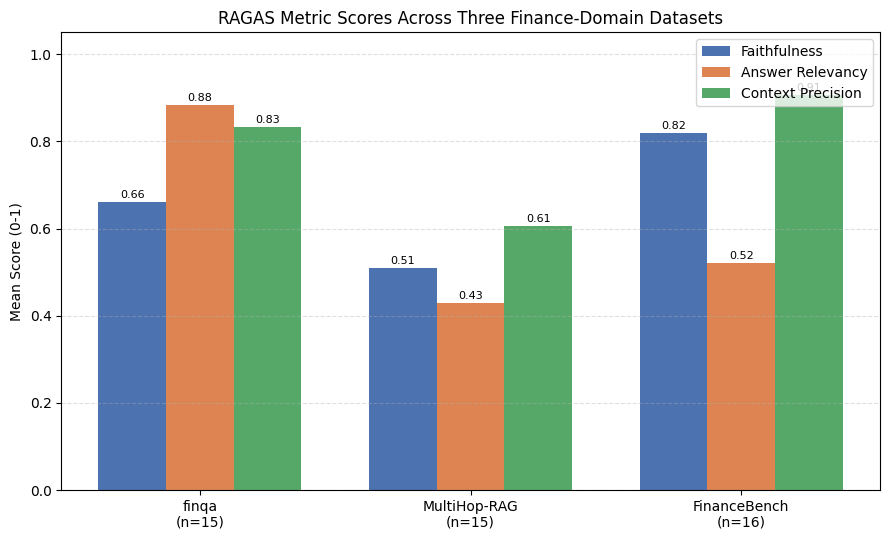

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

datasets_order = ["finqa", "MultiHop-RAG", "FinanceBench"]
n_labels = combined.groupby("dataset").size()

labels = [f"{d}\n(n={n_labels[d]})" for d in datasets_order]
faithfulness_vals = [overall_summary.loc[d, "faithfulness"] for d in datasets_order]
relevancy_vals = [overall_summary.loc[d, "answer_relevancy"] for d in datasets_order]
precision_vals = [overall_summary.loc[d, "context_precision"] for d in datasets_order]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5.5))
bars1 = ax.bar(x - width, faithfulness_vals, width, label="Faithfulness", color="#4C72B0")
bars2 = ax.bar(x, relevancy_vals, width, label="Answer Relevancy", color="#DD8452")
bars3 = ax.bar(x + width, precision_vals, width, label="Context Precision", color="#55A868")

ax.set_ylabel("Mean Score (0-1)")
ax.set_title("RAGAS Metric Scores Across Three Finance-Domain Datasets")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.2f}", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("cross_dataset_metric_comparison.png", dpi=200)
plt.show()


## 6. Chart 2: Faithfulness by calculation/numerical vs. lookup/extraction

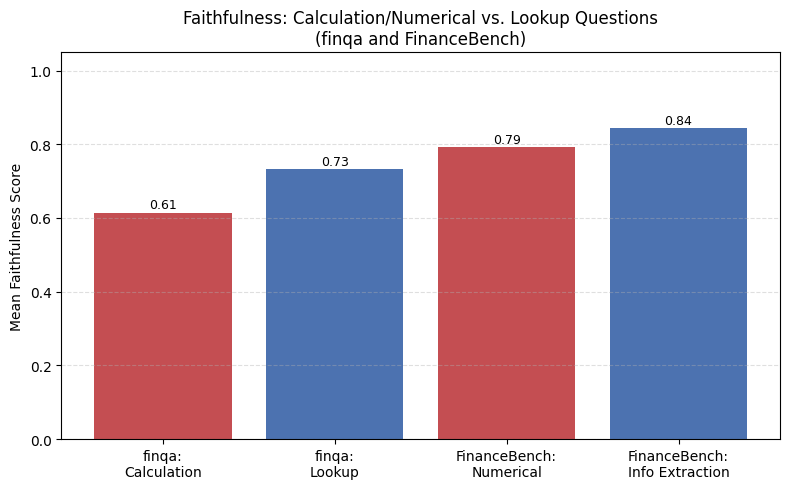

In [ ]:
finqa_by_type = finqa.groupby("question_type")["faithfulness"].mean()
fb_by_type = financebench.groupby("reasoning_bucket")["faithfulness"].mean()

categories = [
    "finqa:\nCalculation", "finqa:\nLookup",
    "FinanceBench:\nNumerical", "FinanceBench:\nInfo Extraction"
]
faithfulness_by_cat = [
    finqa_by_type["calculation"], finqa_by_type["lookup"],
    fb_by_type["Numerical reasoning"], fb_by_type["Information extraction"]
]
colors = ["#C44E52", "#4C72B0", "#C44E52", "#4C72B0"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(categories, faithfulness_by_cat, color=colors)
ax.set_ylabel("Mean Faithfulness Score")
ax.set_title("Faithfulness: Calculation/Numerical vs. Lookup Questions\n(finqa and FinanceBench)")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.4)
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("calculation_vs_lookup_faithfulness.png", dpi=200)
plt.show()


## 7. Files produced

- `all_datasets_combined_results.csv` -- full combined data, useful as an appendix
- `cross_dataset_metric_comparison.png` -- Figure for Evaluation chapter
- `calculation_vs_lookup_faithfulness.png` -- Figure for Evaluation chapter

These, together with the individual per-dataset notebooks, form the complete, reproducible
artefact for this project.
